In [2]:
df = pd.read_csv("/Users/kaanadaleti/Desktop/dsa_proje/tigerwoods.csv")
df.head()

,Time,Tiger Woods,Nike
0,2009-09-27,2,30
1,2009-10-04,2,29
2,2009-10-11,2,29
3,2009-10-18,1,30
4,2009-10-25,1,29


In [5]:
df["Time"] = pd.to_datetime(df["Time"])
df = df.sort_values("Time")

In [7]:
df[["Tiger Woods", "Nike"]].corr()

,Tiger Woods,Nike
Tiger Woods,1.000000,0.723099
Nike,0.723099,1.000000


In [8]:
before = df[df["Time"] < "2009-12-01"]["Tiger Woods"]
after = df[df["Time"] >= "2009-12-01"]["Tiger Woods"]

print("Before mean:", before.mean())
print("After mean:", after.mean())

Before mean: 13.6
After mean: 27.88888888888889


In [9]:
before_nike = df[df["Time"] < "2009-12-01"]["Nike"]
after_nike = df[df["Time"] >= "2009-12-01"]["Nike"]

print("Nike Before:", before_nike.mean())
print("Nike After:", after_nike.mean())

Nike Before: 29.5
Nike After: 29.22222222222222


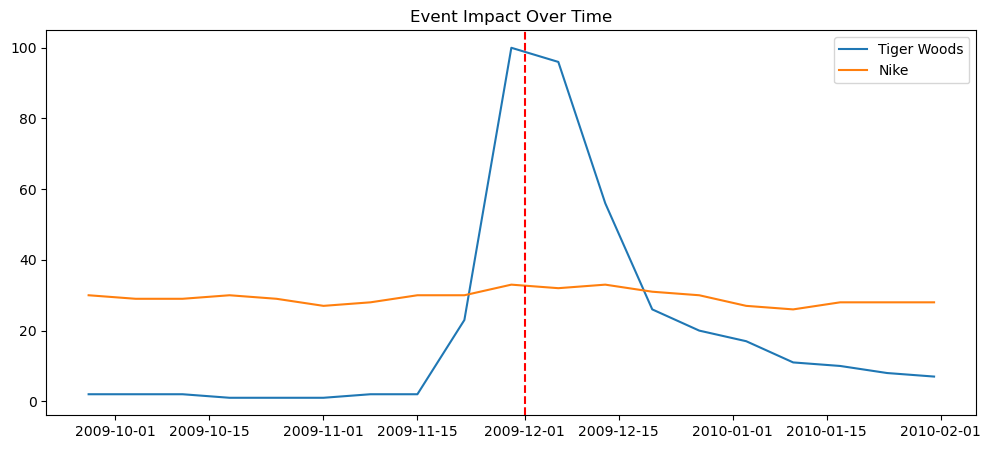

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(df["Time"], df["Tiger Woods"], label="Tiger Woods")
plt.plot(df["Time"], df["Nike"], label="Nike")
plt.axvline(pd.to_datetime("2009-12-01"), color="red", linestyle="--")
plt.legend()
plt.title("Event Impact Over Time")
plt.show()

In [11]:
df["TW_change"] = df["Tiger Woods"].pct_change()
df["Nike_change"] = df["Nike"].pct_change()

df[["TW_change","Nike_change"]].describe()

,TW_change,Nike_change
count,18.000000,18.000000
mean,0.678101,-0.002484
std,2.602686,0.053373
min,-0.535714,-0.100000
25%,-0.223077,-0.033333
50%,-0.065455,0.000000
75%,0.000000,0.033675
max,10.500000,0.100000


In [12]:
event = pd.to_datetime("2009-12-01")

before = df[df["Time"] < event]["Tiger Woods"]
after = df[df["Time"] >= event]["Tiger Woods"]

In [13]:
from scipy.stats import ttest_ind

t_stat, p_value = ttest_ind(before, after, equal_var=False)

print("T-stat:", t_stat)
print("P-value:", p_value)

T-stat: -1.0242408852978926
P-value: 0.3201365190036948


In [14]:
df[["Tiger Woods","Nike"]].corr()

,Tiger Woods,Nike
Tiger Woods,1.000000,0.723099
Nike,0.723099,1.000000


In [ ]:
Although the t-test does not show a statistically significant difference in mean search interest before and after the scandal (p = 0.32), the correlation between Tiger Woods and Nike remains relatively strong (0.72).

This suggests that while both series move together over time, the scandal does not produce a clear shift in average attention levels, but rather affects short-term co-movement patterns.